# HOSVD-GPR — ZOU_GPR dataset

Direct adaptation of `NON_SI_SA_MAI/HOSVD_GPR.ipynb` to the ZOU_GPR dataset.

**Dataset:** 23 available CFD cases (CH4/H2/N2 fuel jet), 2 parameters: Re ∈ {11k–19k}, Y_H2 ∈ {0.04–0.20}.  
**Grid:** 84 radial (x) × 101 axial (z) points.  
**Kernel:** `isi` conda environment (tensorly, gpytorch, scikit-learn required).

In [1]:
import sys
sys.path.insert(0, '/home/isacco/PROJECTS/NON_SI_SA_MAI')

import numpy as np
import tensorly as tl
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from utils import compute_factor, compute_core, PODGPR
from pathlib import Path
import csv

DATA_DIR  = Path('/home/isacco/DATA/ZOU_GPR')
CASES_DIR = DATA_DIR / 'Datasets_Isacco'

# Full column list of the .xy files (44 columns)
_ALL_COLS = [
    'x','y','z','alphat',
    'C2H','C2H2','C2H3','C2H4','C2H5','C2H6','C3H7','C3H8',
    'CH','CH2','CH2CHO','CH2CO','CH2O','CH2OH','CH2S','CH3','CH3CHO','CH3O','CH3OH',
    'CH4','CO','CO2','epsilon','H','H2','H2O','H2O2','HCCO','HCCOH','HCO','HO2',
    'k','N2','O2','OH','p','T','Ux','Uy','Uz'
]
_CI = {name: i for i, name in enumerate(_ALL_COLS)}
print('Imports OK')

Imports OK


## Load data and build the 4-D tensor

Same preprocessing as `HOSVD_GPR.ipynb`: select chemical/thermal features, `log1p` on all 8 species, global standardisation.

Only 23 of 25 cases are available (Case17 and Case22 are missing); P and the tensor are built from existing files only.

In [2]:
# Selected features: 8 reactive species + T + Uz
features     = ['CH4', 'CO', 'CO2', 'H2', 'H2O', 'N2', 'O2', 'OH', 'T', 'Uz']
feat_indices = [_CI[f] for f in features]
n_feat       = len(features)
# log1p applied to the first 8 (all species; T and Uz stay linear)
n_log1p = 8

def load_case(path):
    raw    = np.loadtxt(path, skiprows=1)
    x_vals = np.unique(raw[:, _CI['x']])
    z_vals = np.unique(raw[:, _CI['z']])
    idx    = np.lexsort((raw[:, _CI['x']], raw[:, _CI['z']]))
    grid   = raw[idx].reshape(len(z_vals), len(x_vals), len(_ALL_COLS))
    return grid, x_vals, z_vals

# Read case_summary and keep only available files
with open(DATA_DIR / 'case_summary.csv') as f:
    all_rows = list(csv.DictReader(f))

available = {p.stem for p in CASES_DIR.glob('*.xy')}
rows = [r for r in all_rows if r['case_name'] in available]
rows.sort(key=lambda r: int(r['case_id']))

n_sim = len(rows)
P     = np.array([[float(r['Re']), float(r['Y_H2'])] for r in rows])   # (n_sim, 2)

# Load first case to get grid dimensions
_g0, x_vals, z_vals = load_case(CASES_DIR / (rows[0]['case_name'] + '.xy'))
n_z, n_x = len(z_vals), len(x_vals)

# Build tensor (n_sim, n_feat, n_z, n_x)
tensor_raw = np.zeros((n_sim, n_feat, n_z, n_x))
for i, row in enumerate(rows):
    g, _, _ = load_case(CASES_DIR / (row['case_name'] + '.xy'))
    for j, fi in enumerate(feat_indices):
        tensor_raw[i, j, :, :] = g[:, :, fi]

print(f'Tensor shape: {tensor_raw.shape}')   # (23, 10, 101, 84)
print(f'Features: {features}')
print(f'P shape:  {P.shape}  (Re range {P[:,0].min():.0f}–{P[:,0].max():.0f}, '
      f'Y_H2 range {P[:,1].min():.2f}–{P[:,1].max():.2f})')

Tensor shape: (23, 10, 101, 84)
Features: ['CH4', 'CO', 'CO2', 'H2', 'H2O', 'N2', 'O2', 'OH', 'T', 'Uz']
P shape:  (23, 2)  (Re range 11000–19000, Y_H2 range 0.04–0.20)


In [3]:
# Preprocessing: log1p on species, then global standardisation
tensor = tensor_raw.copy()
tensor[:, :n_log1p, :, :] = np.log1p(tensor[:, :n_log1p, :, :])

mean_pp = tensor.mean(axis=(0, 2, 3), keepdims=True)
std_pp  = tensor.std( axis=(0, 2, 3), keepdims=True)
tensor  = (tensor - mean_pp) / std_pp

print(f'Preprocessed tensor — mean ~0: {tensor.mean():.2e}, std ~1 per feature:')
for j, f in enumerate(features):
    print(f'  {f:6s}  mean={tensor[:,j,:,:].mean():.3f}  std={tensor[:,j,:,:].std():.3f}')

Preprocessed tensor — mean ~0: 3.14e-16, std ~1 per feature:
  CH4     mean=-0.000  std=1.000
  CO      mean=-0.000  std=1.000
  CO2     mean=0.000  std=1.000
  H2      mean=0.000  std=1.000
  H2O     mean=-0.000  std=1.000
  N2      mean=0.000  std=1.000
  O2      mean=-0.000  std=1.000
  OH      mean=-0.000  std=1.000
  T       mean=0.000  std=1.000
  Uz      mean=-0.000  std=1.000


## Test indices on each dimension

In [4]:
test_idx   = [i * 5 for i in range(4)]         # [0, 5, 10, 15]  — 4 test sims
test_idx_z = [i * 10 for i in range(5)]        # [0, 10, 20, 30, 40] — 5 test z
test_idx_x = [i * 20 for i in range(2)]        # [0, 20] — 2 test x

train_idx   = [i for i in range(n_sim) if i not in test_idx]
train_idx_z = [i for i in range(n_z)   if i not in test_idx_z]
train_idx_x = [i for i in range(n_x)   if i not in test_idx_x]

print(f'Sims  — train: {len(train_idx)},  test: {len(test_idx)}')
print(f'z pts — train: {len(train_idx_z)}, test: {len(test_idx_z)}')
print(f'x pts — train: {len(train_idx_x)}, test: {len(test_idx_x)}')

Sims  — train: 19,  test: 4
z pts — train: 96, test: 5
x pts — train: 82, test: 2


## HOSVD on the training tensor

In [5]:
tensor_train = tensor[np.ix_(train_idx, range(n_feat), train_idx_z, train_idx_x)]
print(f'tensor_train shape: {tensor_train.shape}')

U_config  = compute_factor(tensor_train, mode=0)   # (n_train_sim, n_train_sim)
U_feature = compute_factor(tensor_train, mode=1)   # (n_feat, n_feat)
U_z       = compute_factor(tensor_train, mode=2)   # (n_train_z, n_train_z)
U_x       = compute_factor(tensor_train, mode=3)   # (n_train_x, n_train_x)
core      = compute_core(tensor_train, [U_config, U_feature, U_z, U_x])

print(f'core shape: {core.shape}')

tensor_train shape: (19, 10, 96, 82)
core shape: (19, 10, 96, 82)


## GPR to predict factor-matrix rows at test indices

| Factor matrix | Input | Target |
|---|---|---|
| `U_config` | physical params `P` — (Re, Y_H2) | rows of `U_config` |
| `U_z` | z-coordinate (axial) | rows of `U_z` |
| `U_x` | x-coordinate (radial) | rows of `U_x` |

### U_config — GPR over simulation parameters

In [6]:
P_train = P[train_idx, :]   # (n_train_sim, 2)
P_test  = P[test_idx,  :]

r_config   = U_config.shape[1]
gpr_config = PODGPR(U_config.T, n_features=r_config, P_train=P_train)
gpr_config.fit(n_modes=99)
print(f'U_config — POD modes retained: {gpr_config.r}')
gpr_config.train()

A_pred_config, _   = gpr_config.predict(P_test)
U_config_test_pred = gpr_config.reconstruct(A_pred_config).T   # (n_test_sim, r_config)
print(f'U_config_test_pred shape: {U_config_test_pred.shape}')

U_config — POD modes retained: 18
U_config_test_pred shape: (4, 19)


### U_z — GPR over axial coordinate

In [7]:
z_train_coords = z_vals[train_idx_z].reshape(-1, 1)   # (n_train_z, 1)
z_test_coords  = z_vals[test_idx_z ].reshape(-1, 1)

r_z   = U_z.shape[1]
gpr_z = PODGPR(U_z.T, n_features=r_z, P_train=z_train_coords)
gpr_z.fit(n_modes=99)
print(f'U_z — POD modes retained: {gpr_z.r}')
gpr_z.train()

A_pred_z, _  = gpr_z.predict(z_test_coords)
U_z_test_pred = gpr_z.reconstruct(A_pred_z).T   # (n_test_z, r_z)
print(f'U_z_test_pred shape: {U_z_test_pred.shape}')

U_z — POD modes retained: 95
U_z_test_pred shape: (5, 96)


### U_x — GPR over radial coordinate

In [8]:
x_train_coords = x_vals[train_idx_x].reshape(-1, 1)
x_test_coords  = x_vals[test_idx_x ].reshape(-1, 1)

r_x   = U_x.shape[1]
gpr_x = PODGPR(U_x.T, n_features=r_x, P_train=x_train_coords)
gpr_x.fit(n_modes=99)
print(f'U_x — POD modes retained: {gpr_x.r}')
gpr_x.train()

A_pred_x, _  = gpr_x.predict(x_test_coords)
U_x_test_pred = gpr_x.reconstruct(A_pred_x).T   # (n_test_x, r_x)
print(f'U_x_test_pred shape: {U_x_test_pred.shape}')

U_x — POD modes retained: 81
U_x_test_pred shape: (2, 82)


## Assemble full factor matrices

In [9]:
U_config_full = np.zeros((n_sim, r_config))
U_config_full[train_idx, :] = U_config
U_config_full[test_idx,  :] = U_config_test_pred

U_z_full = np.zeros((n_z, r_z))
U_z_full[train_idx_z, :] = U_z
U_z_full[test_idx_z,  :] = U_z_test_pred

U_x_full = np.zeros((n_x, r_x))
U_x_full[train_idx_x, :] = U_x
U_x_full[test_idx_x,  :] = U_x_test_pred

print(f'U_config_full: {U_config_full.shape}')
print(f'U_z_full:      {U_z_full.shape}')
print(f'U_x_full:      {U_x_full.shape}')

U_config_full: (23, 19)
U_z_full:      (101, 96)
U_x_full:      (84, 82)


## Reconstruct the full tensor

In [10]:
tensor_rec = tl.tenalg.multi_mode_dot(
    core,
    [U_config_full, U_feature, U_z_full, U_x_full],
    modes=[0, 1, 2, 3]
)
print(f'Reconstructed tensor shape: {tensor_rec.shape}')

Reconstructed tensor shape: (23, 10, 101, 84)


## Evaluation

In [11]:
def rel_error(T_true, T_pred):
    return np.linalg.norm(np.subtract(T_true, T_pred)) / np.linalg.norm(T_true)

e_total = rel_error(tensor, tensor_rec)
print(f'Overall relative error (full tensor):               {e_total:.5f}')

T_true_test_sim = tensor[np.ix_(test_idx,  range(n_feat), train_idx_z, train_idx_x)]
T_pred_test_sim = tensor_rec[np.ix_(test_idx,  range(n_feat), train_idx_z, train_idx_x)]
print(f'Test sims  / training spatial:                       {rel_error(T_true_test_sim, T_pred_test_sim):.5f}')

T_true_test_sp  = tensor[np.ix_(train_idx, range(n_feat), test_idx_z, test_idx_x)]
T_pred_test_sp  = tensor_rec[np.ix_(train_idx, range(n_feat), test_idx_z, test_idx_x)]
print(f'Training sims / test spatial:                        {rel_error(T_true_test_sp, T_pred_test_sp):.5f}')

T_true_both = tensor[np.ix_(test_idx, range(n_feat), test_idx_z, test_idx_x)]
T_pred_both = tensor_rec[np.ix_(test_idx, range(n_feat), test_idx_z, test_idx_x)]
print(f'Test sims  / test spatial (doubly unseen):           {rel_error(T_true_both, T_pred_both):.5f}')

Overall relative error (full tensor):               0.08289
Test sims  / training spatial:                       0.14104
Training sims / test spatial:                        0.23345
Test sims  / test spatial (doubly unseen):           0.26107


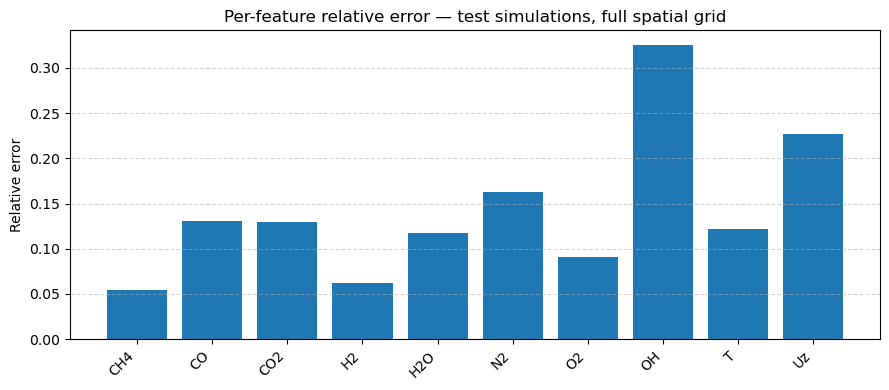

In [12]:
# Per-feature relative error on test simulations (full spatial grid)
errors_per_feat = []
for j in range(n_feat):
    T_true_j = tensor    [np.ix_(test_idx, [j], range(n_z), range(n_x))].ravel()
    T_pred_j = tensor_rec[np.ix_(test_idx, [j], range(n_z), range(n_x))].ravel()
    errors_per_feat.append(rel_error(T_true_j, T_pred_j))

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(range(n_feat), errors_per_feat, color='C0')
ax.set_xticks(range(n_feat))
ax.set_xticklabels(features, rotation=45, ha='right')
ax.set_ylabel('Relative error')
ax.set_title('Per-feature relative error — test simulations, full spatial grid')
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Visual comparison — ground truth vs reconstruction

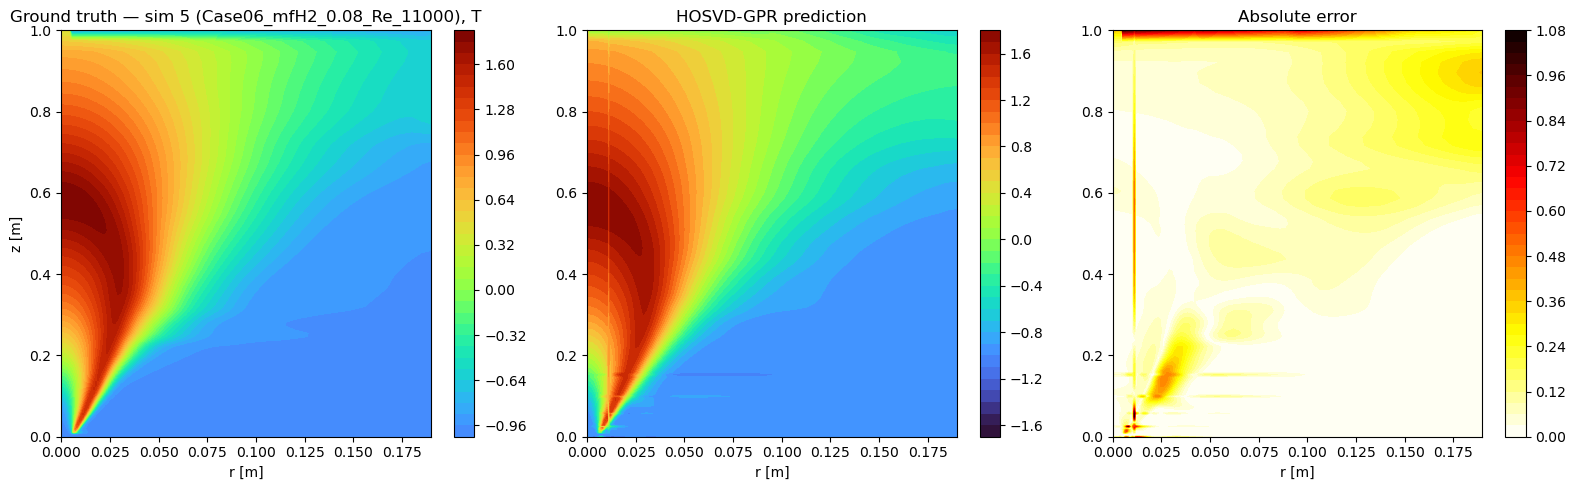

In [13]:
sim_to_show  = test_idx[1]                     # second test simulation
feat_to_show = features.index('T')             # temperature field

T_true_slice = tensor    [sim_to_show, feat_to_show, :, :]
T_pred_slice = tensor_rec[sim_to_show, feat_to_show, :, :]

vmin = min(T_true_slice.min(), T_pred_slice.min())
vmax = max(T_true_slice.max(), T_pred_slice.max())
XX, ZZ = np.meshgrid(x_vals, z_vals)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

im0 = axes[0].contourf(XX, ZZ, T_true_slice, levels=40, cmap='turbo', vmin=vmin, vmax=vmax)
axes[0].set_title(f'Ground truth — sim {sim_to_show} ({rows[sim_to_show]["case_name"]}), {features[feat_to_show]}')
axes[0].set_xlabel('r [m]'); axes[0].set_ylabel('z [m]')
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].contourf(XX, ZZ, T_pred_slice, levels=40, cmap='turbo', vmin=vmin, vmax=vmax)
axes[1].set_title('HOSVD-GPR prediction')
axes[1].set_xlabel('r [m]')
plt.colorbar(im1, ax=axes[1])

im2 = axes[2].contourf(XX, ZZ, np.abs(T_true_slice - T_pred_slice), levels=40, cmap='hot_r')
axes[2].set_title('Absolute error')
axes[2].set_xlabel('r [m]')
plt.colorbar(im2, ax=axes[2])

plt.tight_layout()
plt.show()

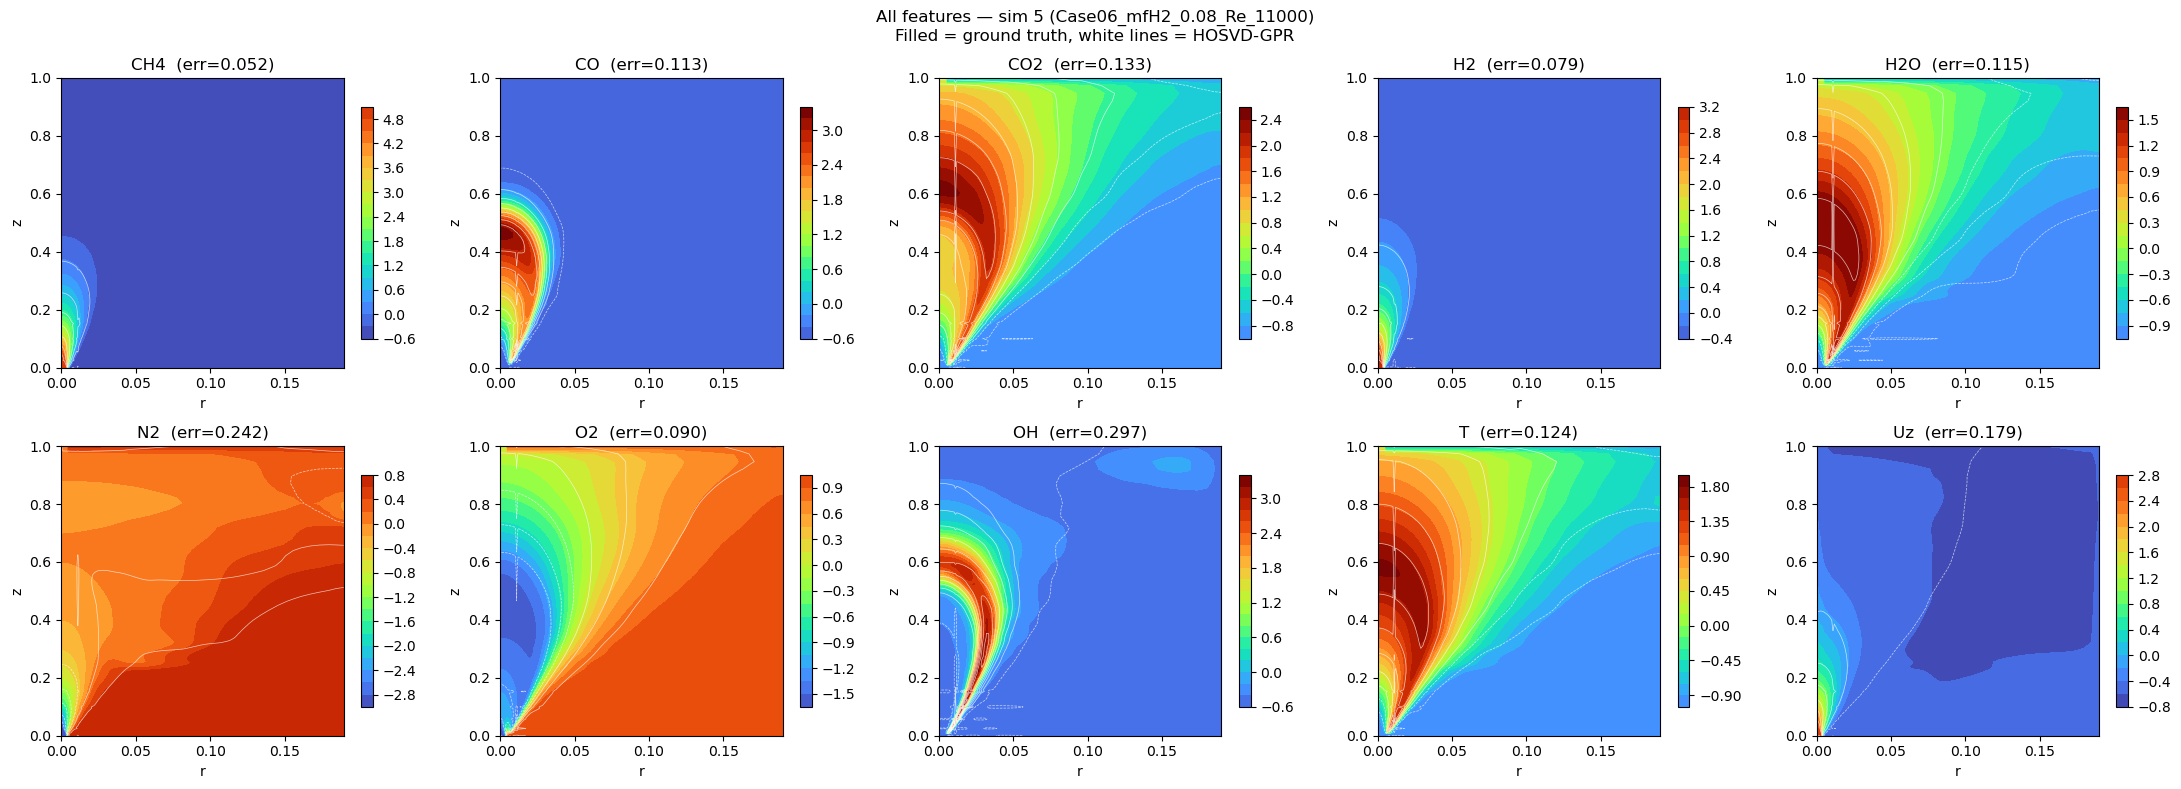

In [14]:
# Grid of all 10 features for the same test simulation
fig, axes = plt.subplots(2, 5, figsize=(22, 8))

for j, (ax, fname) in enumerate(zip(axes.ravel(), features)):
    true_f = tensor    [sim_to_show, j, :, :]
    pred_f = tensor_rec[sim_to_show, j, :, :]
    vmin_f = min(true_f.min(), pred_f.min())
    vmax_f = max(true_f.max(), pred_f.max())
    # show true as filled contour and overlay pred as contour lines
    cf = ax.contourf(XX, ZZ, true_f, levels=20, cmap='turbo', vmin=vmin_f, vmax=vmax_f)
    ax.contour(XX, ZZ, pred_f, levels=10, colors='white', linewidths=0.5, alpha=0.7)
    plt.colorbar(cf, ax=ax, shrink=0.8)
    ax.set_title(f'{fname}  (err={rel_error(true_f, pred_f):.3f})')
    ax.set_xlabel('r'); ax.set_ylabel('z')

fig.suptitle(f'All features — sim {sim_to_show} ({rows[sim_to_show]["case_name"]})\n'
             f'Filled = ground truth, white lines = HOSVD-GPR', fontsize=12)
plt.tight_layout()
plt.show()